# Support Vector Machine (SVM)

## SVC (Support Vector Classification)
- klasszifikácó __maximális margó__ mellett 
- $\underline{w}\cdot\underline{x}+b$ döntési határtól (hipersík, __optimal separating hyperplane__)
- robosztus (hibatűrő) osztályozás (amennyiben a training adatok jók) 
- az osztályok legközelebbi pontjait (támasztó pontok, __support vectors__) tekinti
- független a minták számától, kiegyensúlyozottságától (elvileg, de az implementáció már nem feltétlenül)
- C: misclassification költség
- nagy C érték, "__hard margin__" kasszifikáció, tökéletes szeparálást keres, kis margó
- kis C érték: engedékeny (néha jobb általánosítás), nem tökéletesen szeparálható problémákra is használható
- __kernel trükk__ (kernel trick):
    - mivel az optimális megoldás (keresése) csak az input vektorok skaláris szorzatától függ: <xi, xj>,
    - ha transzformáljuk a pontokat egy másik térbe φ(xi), ahol a skaláris szorzat könnyen számítható (<φ(xi), φ(xj)> = K(<xi, xj>))
    - nem kell a pontokat egyenként transzformálni (néha nem is lehet, mégis a skaláris szorzat számítható)
- kernel transzformációk: 
    - __Linear kernel__ (nincs transzormáció): K(<xi , xj>) = <xi, xj>
    - __Polinomiális kernel__: K(<xi , xj>) = (<xi, xj> + c )$^d$
    - __RBF (Radial Basis Function) kernel__: K(<xi, xj>)=$e^{−γ\|xi −xj\|^2}$ (γ: mennyire kövesse le a határpontokat a döntési határ, kis γ: simább, általánosító, nagy γ: sok görbölet, pontosabb, de overfitting lehet)
- az SVM  a kernel trükk segítségével képes elipszoid, görbe határokat húzni (Logit, LDA nem)
    - koncentrikus körök 
    - __two moons__ probléma

## SVR (Support Vector Regression)
- a cél egy margin meghatározása, amelyben a legtöbb adatpont benne van
- támogatja a lineáris és nem lineáris regressziós modelleket (pl. RBF kernel)

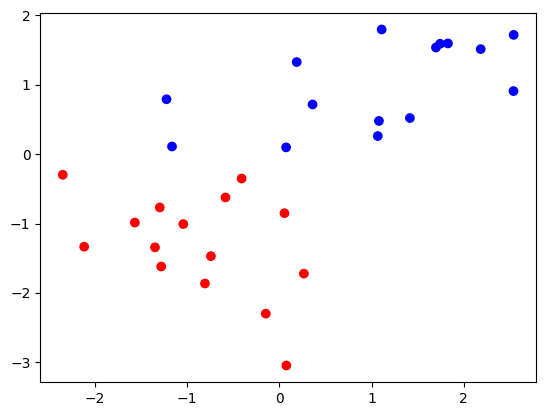

In [6]:
# !pip install scikit-learn
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=30, n_features=2, n_classes=2, n_redundant=0, n_clusters_per_class=1, random_state=40)

import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr) # bwr: 0=blue, 1=red (0.5: white)

In [7]:
from sklearn.svm import SVC # support vector classifier, svr: support vector regression
import numpy as np

svm = SVC(kernel='linear', C=1000) # C: mennyire büntetjük a hibákat
svm.fit(X, y)
print("coeffs:", svm.coef_, "intercept:", svm.intercept_) # w, b


coeffs: [[-0.12664361 -4.53417564]] intercept: [-0.64329367]


## Döntési határ vizualizációja

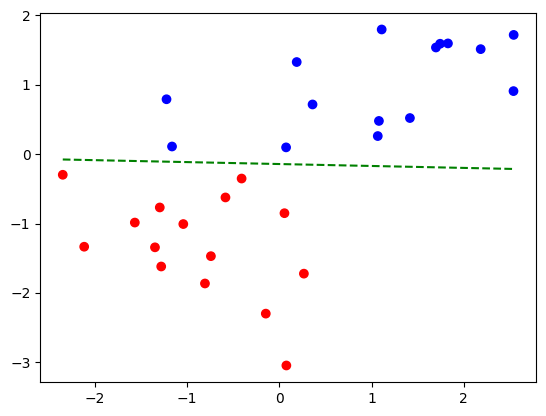

In [8]:
# "szokásos" csak lineáris kernelnél működik
# coef_ is only available when using a linear kernel!
w0 = svm.intercept_[0]
w1 = svm.coef_[0, 0]
w2 = svm.coef_[0, 1]
x_min = X[:,0].min()
x_max = X[:,0].max()
plt.plot([x_min, x_max], [-(w1/w2) * x_min - (w0/w2), -(w1/w2) * x_max - (w0/w2)], color='green', linestyle='--')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr)

(2500, 2)

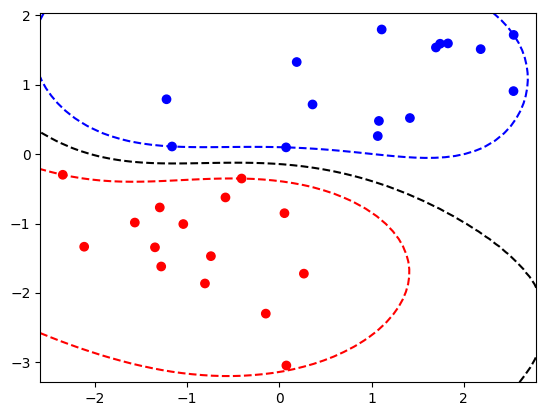

In [19]:
# svm = SVC(kernel='linear', C=10)
# svm = SVC(kernel='linear', C=1)
# svm = SVC(kernel='linear', C=0.1)
svm = SVC(kernel='rbf', C=100) # max_iter: -1 (default), 0 (no limit), >0 (max iterációk száma) - igy nem futhat tul sokaig
# svm = SVC(kernel='rbf', C=1)
# svm = SVC(kernel='rbf', C=0.1)
# svm = SVC(kernel='poly', C=0.1)
# svm = SVC(kernel='poly', C=1)
# svm = SVC(kernel='poly', C=100)
svm.fit(X, y)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.bwr)
ax = plt.gca() # get axes
xlim = ax.get_xlim() # chart lowest/highest x coordinate (-2.2237468164090393, 2.7932941783305356)
ylim = ax.get_ylim() # chart lowest/highest y coordinate (-3.504647659970657, 0.901283704190678)

# grid
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50)) 
# mesh_points = np.c_[xx.ravel(), yy.ravel()] # c_=column stack (hstack); ravel==flatten (without copy)
# plt.scatter(xx.ravel(), yy.ravel(), color='green', marker=".", alpha=0.2, s=2) # mesh, s: size

Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) # egy decision score-t számít (confidence)

# hosszabban...
xy = np.column_stack([xx.flatten(), yy.flatten()]) # (2500, 2), == np.c_
# xy = np.hstack([xx.flatten().reshape(2500,1), yy.flatten().reshape(2500,1)]) # (2500, 2), 
z = svm.decision_function(xy) 
Z = z.reshape(xx.shape) # (50, 50), mert a contour ugyanolyan shape-el várja a z-t, mint az x és y-okat

plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "black", "red"], linestyles="dashed") # colors="black",
xy.shape

Predictions: [1 1 0 0 0]
Decision function values: [ 2.92404744  2.88043962 -0.58960664 -3.41220342 -2.70532163]


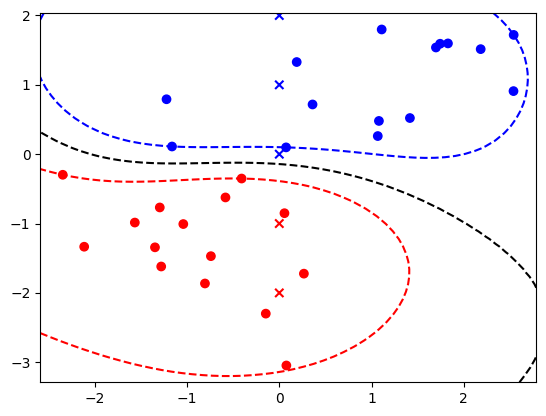

In [124]:
new_points = np.array([[0, -2], [0, -1], [0, 0], [0, 1], [0, 2]])

predictions = svm.predict(new_points)
decision_values = svm.decision_function(new_points)
print("Predictions:", predictions) # class labels (based on decision scores)
print("Decision function values:", decision_values) # decision score
#Predictions: [1 1 0 0 0]
#Decision function values: [ 8.4250576   3.89088196, -0.64329367 -5.17746931 -9.71164495]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr)
plt.scatter(new_points[:, 0], new_points[:, 1], c=predictions, cmap=plt.cm.bwr, marker="x")
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "black", "red"], linestyles="dashed")


# Nemlineáris probléma

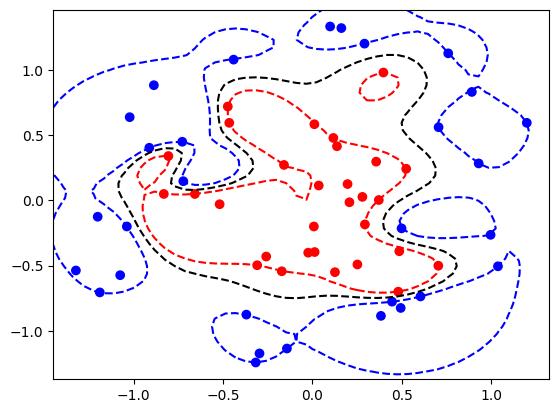

In [125]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=60, noise=0.25, factor=0.5, random_state=42)

svm = SVC(kernel='rbf', C=0.0001, gamma='scale')
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm = SVC(kernel='rbf', C=1000, gamma=0.1)
svm = SVC(kernel='rbf', C=1000, gamma=1)
svm = SVC(kernel='rbf', C=1000, gamma=10)

svm.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr)
xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "black", "red"], linestyles="dashed") # colors="black",

In [126]:
from sklearn.metrics import classification_report

y_pred = svm.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



## Multiclass

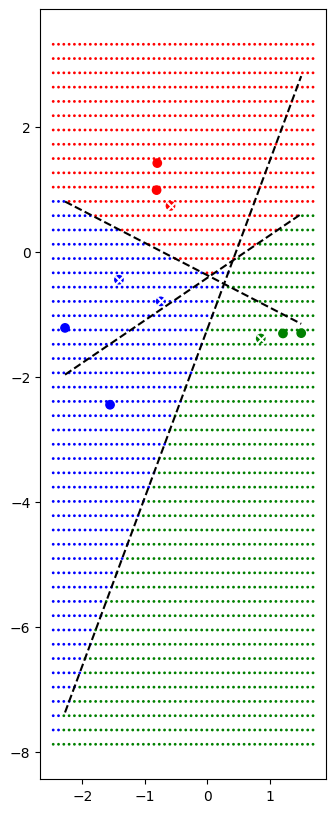

In [131]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=10, n_features=2, n_classes=3, n_redundant=0, n_clusters_per_class=1, random_state=5)

import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plt.gca().set_aspect('equal')

colormap = np.array(['blue', 'green', 'red'])
plt.scatter(X[:, 0], X[:, 1], c=colormap[y])

from sklearn.svm import SVC
model = SVC(kernel="linear", decision_function_shape="ovo") # ovo: one-vs-one, ovr: one-vs-rest
model.fit(X, y)

for i in range(0, model.coef_.shape[0]):
    w0 = model.intercept_[i]
    w1 = model.coef_[i, 0]
    w2 = model.coef_[i, 1]
    x_min = X[:,0].min() / 1
    x_max = X[:,0].max() / 1
    plt.plot([x_min, x_max], [-(w1/w2) * x_min - (w0/w2), -(w1/w2) * x_max - (w0/w2)], color="black", linestyle='--')

import numpy as np
xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
# plt.scatter(xx, yy, c=Z, s=1, cmap=plt.cm.brg)
plt.scatter(xx, yy, s=1, c=colormap[Z.flatten()])

plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1], c="white", marker="x")

## Support Vector Regression

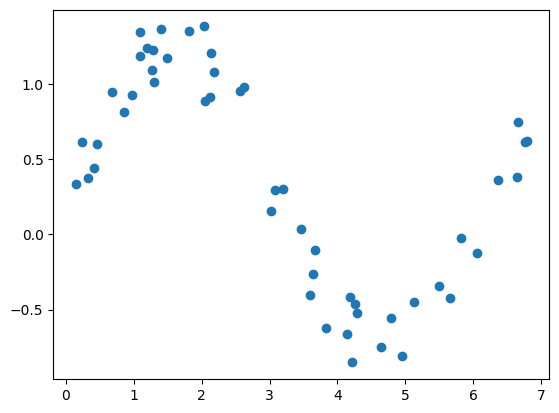

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

np.random.seed(42)
X = 7 * np.random.rand(50, 1)
y = np.sin(X) + 0.5 * np.random.rand(50, 1)
y = np.reshape(y, (50,))
plt.scatter(X, y)

Text(0, 0.5, 'y')

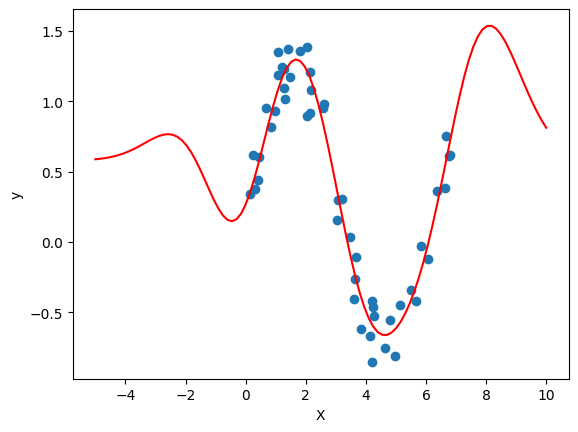

In [128]:
svr = SVR(kernel='rbf', C=100, gamma='scale')
svr.fit(X, y)
X_test = np.reshape(np.linspace(-5, 10, 100), (100,1))
y_pred = svr.predict(X_test)
plt.scatter(X, y)
plt.plot(X_test, y_pred, color='red')
plt.xlabel("X")
plt.ylabel("y")

# Feladat

- "Ionosphere dataset": az ionoszférából visszaérkező radarjelek "jó" vagy "rossz" kategóriába sorolása
- a "jó" radarhozamok azok, amelyek az ionoszféra valamilyen szerkezetére utalnak, míg a "rossz" eredmények azok, amelyek nem; jeleik áthaladnak az ionoszférán
- https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data
- utolsó oszlop (35.) a célváltozó, "g": good, "b": bad értékeket vesznek fel, minden más input feature-nek tekintendő
- cél:
    - adatok betöltése, előfeldolgozása
    - bináris klasszifikáció alkalmazása: Logisztikus regresszió, LDA és SVM 
    - eredmények kiértékelése, teljesítmény összehasonlítása (classification report, conf. matrix)


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
column_names = [f"feature_{i+1}" for i in range(34)] + ["target"]
df = pd.read_csv(url, names=column_names)



X = df.drop(columns="target") # axis = 1 mert oszlopot akarunk törölni, axis=0 lenne, ha sorokat akarnánk törölni
df["target"] = df["target"].apply(lambda x: 1 if x == "g" else 0) # g: good, b: bad
y = df["target"]

svm = SVC(kernel='linear', C=1)
svm.fit(X, y)
y_pred = svm.predict(X)
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

# logistic regression
log_reg = LogisticRegression()
log_reg.fit(X, y)
y_pred_log_reg = log_reg.predict(X)
print(classification_report(y, y_pred_log_reg))
print(confusion_matrix(y, y_pred_log_reg))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89       126
           1       0.91      0.98      0.94       225

    accuracy                           0.92       351
   macro avg       0.93      0.90      0.91       351
weighted avg       0.93      0.92      0.92       351

[[104  22]
 [  5 220]]
